<style>
p { max-width: 80em;}
</style>

## <span style="color:#ce4356">4 </span>  - Bayesian renaissance: MCMC

In [106]:
import numpy as np
import matplotlib.pyplot as plt
import corner
from scipy.integrate import solve_ivp
# good colormaps 
from cmcrameri import cm as cmc
from cmocean import cm as cm
colors = np.vstack([cm.dense([0.25, 0.5, 0.95]),
                    cmc.acton([0.5, 0.85]),
                    cm.matter([0.1, 0.45]),
                    cm.algae([0.5,0.95])])

Bayesian inference is old — Bayes' theorem dates to the 1700s. But for most of the twentieth century it was held back by computation: to get from prior and likelihood to posterior, you need to integrate, and outside a few special cases that integral has no closed form. This changed with the arrival of MCMC (Metropolis 1953, generalised by Hastings 1970; Gibbs sampling, popularised in the 1990s), hence the renaissance: Bayesian methods became a standard tool in genetics, econometrics, ML, astrophysics and beyond.

### Why we need <span style="color:#ce4356">sampling</span>

Two things might happen as soon as a model is realistic:

- **The posterior has no closed form.** Outside conjugate cases like the buns, prior × likelihood is not a named distribution.
- **There are many parameters - multidimensional space.**

Almost everything we report is an integral over that posterior, e.g.:

$$
\begin{aligned}
\text{marginal:}&\quad P(\theta_1 \mid \text{Data}) = \int P(\vec\theta \mid \text{Data})\, d\theta_2 \cdots d\theta_d \\
\text{interval:}&\quad \int_a^b P(\theta_1 \mid \text{Data})\, d\theta_1 = 0.68 \\
\text{prediction:}&\quad P(y_\text{new} \mid \text{Data}) = \int P(y_\text{new} \mid \vec\theta)\, P(\vec\theta \mid \text{Data})\, d\vec\theta \\
\text{evidence:}&\quad P(\text{Data}) = \int P(\text{Data} \mid \vec\theta)\, P(\vec\theta)\, d\vec\theta
\end{aligned}
$$

The integrand we can only probe point by point: prior × likelihood, evaluated at one $\vec\theta$ at a time, over a high-dimensional landscape we do not know in advance.

### The curse of dimensionality - <span style="color:#ce4356">the BIG orange</span>

Assume our posterior is a multidimensional Gaussian. In two dimensions we can visualize our "orange" like this:

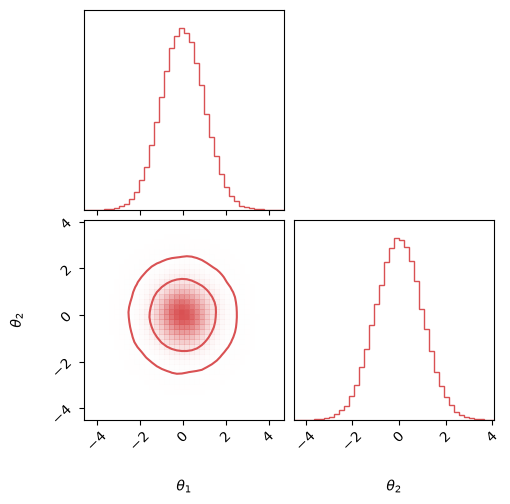

In [107]:
rng = np.random.default_rng(0)
blob = rng.standard_normal((10**5, 2))

corner.corner(blob, labels=[r"$\theta_1$", r"$\theta_2$"], color=colors[6], plot_datapoints=False,
              bins=40, smooth=1.0, levels=(0.68, 0.95), hist_kwargs=dict(density=True))
plt.show()

Now let's make the orange $d$-dimensional and integrate it naively, on a grid or with uniform random points. Take the orange to be the ball that holds the posterior, and cover only the orange, not the box around it. Both spread their points evenly in volume, so their share of points in the peel (the tail of the Gaussian) is the peel's share of the volume. In $d$ dimensions the volume of the orange is

$$V_d(R) = \frac{\pi^{d/2}}{\Gamma(d/2 + 1)}\, R^d$$

so the peel, the outer 5% of the radius, has volume

$$V_\text{peel} = V_d(R) - V_d(0.95\,R) = V_d(R)\,\left(1 - 0.95^{\,d}\right)$$

In [108]:
from scipy.special import gammaln
from bayes_tools import html_table

def ball_volume(d, R=1.0):
    return np.exp(0.5 * d * np.log(np.pi) - gammaln(0.5 * d + 1)) * R ** d

rows = []
for d in [2, 6, 10, 100]:
    orange, core = ball_volume(d), ball_volume(d, 0.95)
    rows.append([d, f"{float(100 ** d):.0e}", f"{(orange - core) / orange:.1%}"])

html_table(["d", "grid points, 100 per axis", "volume of the 5% peel, as a share of the orange"],
           rows, rule_before_last=False)

d,"grid points, 100 per axis","volume of the 5% peel, as a share of the orange"
2,1e+04,9.8%
6,1e+12,26.5%
10,1e+20,40.1%
100,1e+200,99.4%


1. **The grid is not feasible:** $100^d$ points, already $10^{12}$ at $d = 6$.
2. **the volume of the orange is in its peel:** $40.1\%$ of it at $d = 10$, where the posterior is negligible.

We need sample points that go where the probability is: a Markov chain.

# <span style="color:#ce4356">Markov Chain Monte Carlo</span>

Markov Chain Monte Carlo is a family of algorithms for drawing samples from a probability distribution — here, the posterior — when you can't sample from it directly, but you can evaluate something proportional to its density (prior × likelihood).

MCMC builds a random walk that spends time in each region of parameter space in proportion to its posterior probability — so, given enough steps, the samples it visits approximate the posterior itself.

There are many different MCMC algorithms, and which works best depends on the question and on the shape of the posterior. The classic Metropolis–Hastings algorithm is described in the handwritten notes. To explore others, a very good resource is the [interactive MCMC demo](https://chi-feng.github.io/mcmc-demo/).

---
## <span style="color:#ce4356">Example 4.1 </span>  — foxes and rabbits

Foxes reach the island. The rabbits are no longer held back by the grass but by predation:

$$\frac{dR}{dt} = \underbrace{\alpha R}_{\textstyle\color{#888888}\text{births}}
- \underbrace{\beta R F}_{\textstyle\color{#888888}\text{eaten}}
\qquad\qquad
\frac{dF}{dt} = \underbrace{\delta R F}_{\textstyle\color{#888888}\text{births}}
- \underbrace{\gamma F}_{\textstyle\color{#888888}\text{deaths}}$$

$R$ rabbits, $F$ foxes: rabbits breed on their own and die only by being eaten, foxes die on their own and breed only by eating.

| parameter | meaning | unit |
|:---|:---|:---|
| $\alpha$ | rabbit birth rate — with no foxes, $\dot R = \alpha R$ | 1/yr |
| $\beta$ | each fox eats a fraction $\beta$ of the rabbits per year | 1/(fox·yr) |
| $\delta$ | fox birth rate from feeding — each rabbit adds $\delta$ per year to the birth rate of each fox | 1/(rabbit·yr) |
| $\gamma$ | fox death rate — with no rabbits, $\dot F = -\gamma F$ | 1/yr |

The product $RF$ assumes a well-mixed island: encounters happen at a rate proportional to $R \times F$. Set $\beta = 0$ and the first equation is the exponential model that opened Example 3.1.

The system has no closed-form solution, so every evaluation of the likelihood runs an ODE solver. There are six parameters, $\vec\theta = (\alpha, \beta, \delta, \gamma, R_0, F_0)$. The survey is the one from lecture 3, now counting both species once a year, with an error of about 15%. The posterior is similar to Example 3.1:

$$
P\big(\vec\theta \mid \underbrace{\{R_i, F_i\}}_{\textstyle\color{#888888}\text{Data}}\big)
\;\propto\;
\underbrace{P(\vec\theta)}_{\textstyle\color{#888888}\text{priors}}
\;\;
\underbrace{\exp\left[-\tfrac12 \sum_i \left(\frac{R_i - R(t_i;\, \vec\theta)}{\sigma R_i}\right)^{\!2}
-\tfrac12 \sum_i \left(\frac{F_i - F(t_i;\, \vec\theta)}{\sigma F_i}\right)^{\!2}\right]}_{\textstyle\color{#888888}\text{likelihood}}
$$

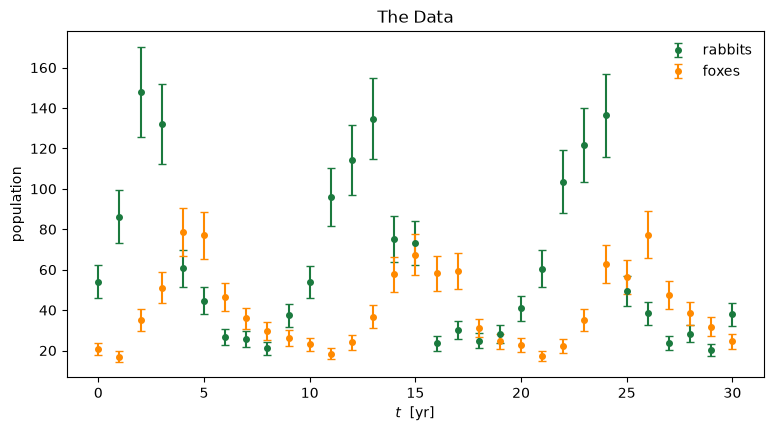

In [109]:
def lotka_volterra(t, y, alpha, beta, delta, gamma):
    R, F = y
    return [alpha * R - beta * R * F,
            delta * R * F - gamma * F]

def evolve(theta, t):
    '''Forward model: every call runs the solver.'''
    alpha, beta, delta, gamma, R0, F0 = theta
    sol = solve_ivp(lotka_volterra, (0, t[-1]), [R0, F0], t_eval=t,
                    args=(alpha, beta, delta, gamma), rtol=1e-6, atol=1e-6)     # far below the 15% noise
    return sol.y                       # shape (2, len(t)):  rabbits, foxes

theta_true = [0.8, 0.02, 0.008, 0.5, 60.0, 20.0]
labels = [r"$\alpha$", r"$\beta$", r"$\delta$", r"$\gamma$", "$R_0$", "$F_0$"]

t_survey = np.arange(0, 31, 1.0)       # one survey a year for thirty years
sigma_frac = 0.15

rng = np.random.default_rng(4)
truth = evolve(theta_true, t_survey)
counts = truth * (1 + sigma_frac * rng.standard_normal(truth.shape))
sig = sigma_frac * counts

t_smooth = np.linspace(0, 30, 600)

c_rabbit, c_fox = "#1b7a3e", "#ff8a00"      # species colours, clear of the acton map

fig, ax = plt.subplots(figsize=(9, 4.5))
for k, (name, c) in enumerate([("rabbits", c_rabbit), ("foxes", c_fox)]):
    ax.errorbar(t_survey, counts[k], sig[k], fmt="o", ms=4, capsize=3, color=c, label=name)

ax.set_xlabel("$t$  [yr]"); ax.set_ylabel("population")
ax.grid(False); ax.legend(frameon=False)
plt.title("The Data")
plt.show()

Flat priors on a box: $\alpha \in [0, 2]$, $\beta \in [0, 0.1]$, $\delta \in [0, 0.05]$, $\gamma \in [0, 2]$, $R_0 \in [0, 200]$, $F_0 \in [0, 100]$.

In [110]:
import time

bounds = np.array([[0, 2], [0, 0.1], [0, 0.05], [0, 2], [0, 200], [0, 100]])   # flat priors: the box

def log_post(theta):
    if np.any(theta <= bounds[:, 0]) or np.any(theta >= bounds[:, 1]):
        return -np.inf                                                        # zero prior outside the box
    return -0.5 * (((counts - evolve(theta, t_survey)) / sig) ** 2).sum()  # Sum over all likelihoods (prior is flat)

t_start = time.perf_counter()
for _ in range(100):
    evolve(theta_true, t_survey)
cost = (time.perf_counter() - t_start) / 100

print(f"one solve:                  {cost * 1e3:.1f} ms")
print(f"grid, 100 points per axis:  {100 ** 6 * cost / 3.15e7:,.0f} years")

one solve:                  2.1 ms
grid, 100 points per axis:  65 years


### Sampling with `emcee` library

`emcee` (Goodman & Weare 2010) is an affine invariant ensemble version of Metropolis–Hastings. For the details, see the [emcee documentation](https://emcee.readthedocs.io/en/stable/). What is different:

- Many walkers, not one. We run 32 at once, starting near the best fit that an optimiser found.
- The proposal comes from the other walkers.
- The same accept/reject rule. The new point is kept with the usual Metropolis ratio of posteriors, times a Hastings correction.

In [111]:
import emcee
from scipy.optimize import minimize

# a starting guess read off the data: the mean levels and a ten-year cycle
R_star, F_star = counts[0].mean(), counts[1].mean()
rate = 2 * np.pi / 10.0                                   # sqrt(alpha * gamma), split evenly
guess = np.array([rate, rate / F_star, rate / R_star, rate, counts[0, 0], counts[1, 0]])
start = minimize(lambda th: -log_post(th), guess, method="Nelder-Mead",
                 options=dict(maxiter=20000, xatol=1e-8, fatol=1e-8)).x

n_walkers, n_steps = 32, 2000
p0 = start * (1 + 1e-3 * np.random.default_rng(0).standard_normal((n_walkers, len(start))))   # a tiny ball around the start
sampler = emcee.EnsembleSampler(n_walkers, len(start), log_post)
sampler.run_mcmc(p0, n_steps)                             # about two minutes on my mac

flat = sampler.get_chain(discard=400, thin=10, flat=True)          # drop the walk in from the start
log_weight = sampler.get_log_prob(discard=400, thin=10, flat=True) # log posterior of every sample, stored by emcee
print(f"acceptance {sampler.acceptance_fraction.mean():.0%}")

acceptance 48%


### <span style="color:#ce4356">a) </span> The joint posterior

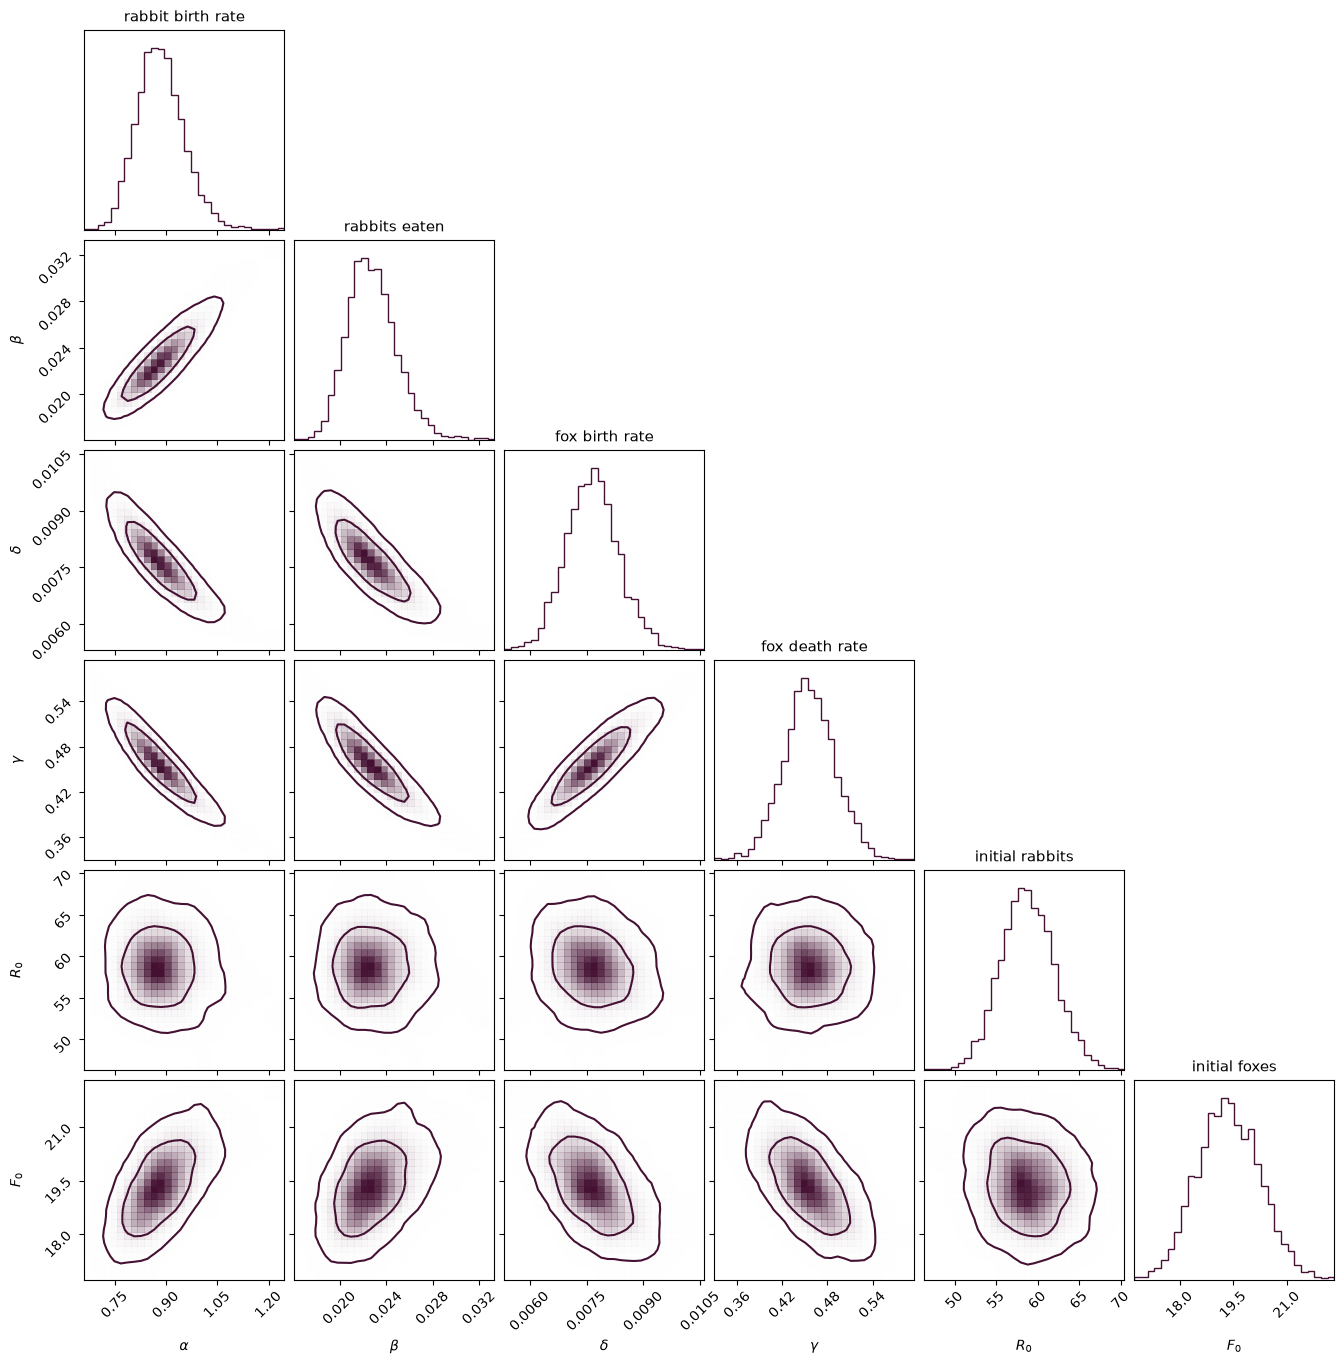

In [112]:
names = ["rabbit birth rate", "rabbits eaten", "fox birth rate", "fox death rate", "initial rabbits", "initial foxes"]

corner.corner(flat, labels=labels, titles=names, show_titles=True, title_fmt=None, title_kwargs=dict(fontsize=11),
              color=colors[2], plot_datapoints=False, bins=30, smooth=1.0, levels=(0.68, 0.95))
plt.show()

### <span style="color:#ce4356">b) </span> Back to the data

Each sample is a full set of parameters, run forward. Left: every curve coloured by the posterior weight of its sample, relative to the best one. Right: the 68% and 95% credible intervals of the same curves at each time.

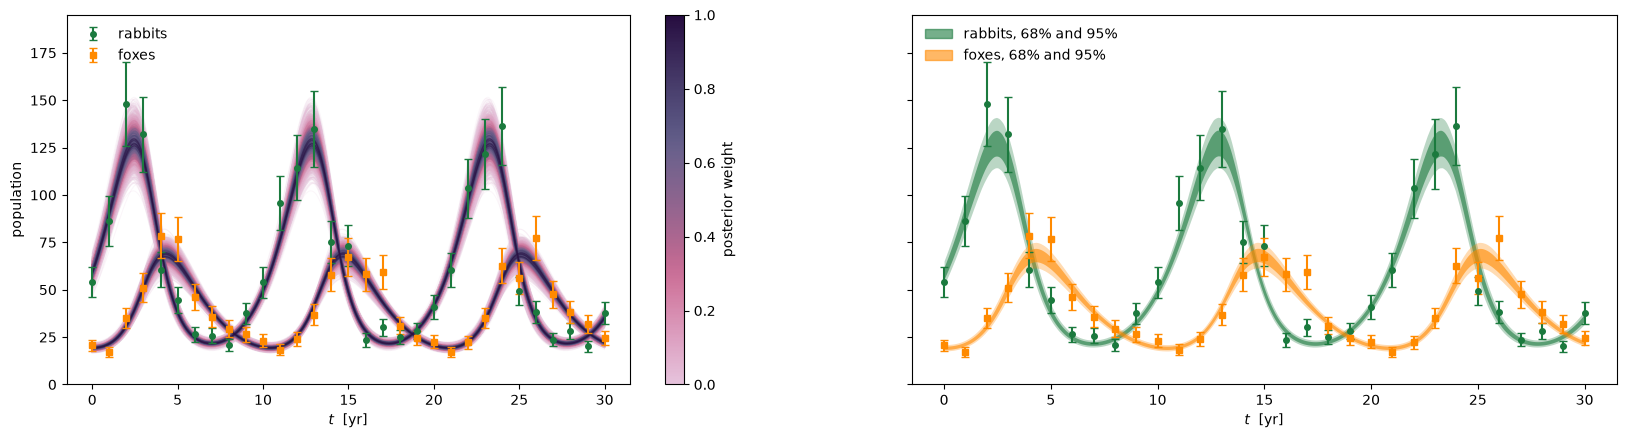

In [113]:
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap

curves = np.array([evolve(th, t_smooth) for th in flat])         # every sample run forward: (samples, species, time)
weight = np.exp(log_weight - log_weight.max())                   # posterior weight, relative to the best sample
lo95, lo68, hi68, hi95 = np.quantile(curves, [0.025, 0.16, 0.84, 0.975], axis=0)
cmap = ListedColormap(cmc.acton_r(np.linspace(0.15, 1, 256)))    # the lowest weight stays visible

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 4.8), sharey=True)

for j in np.argsort(weight):                                     # the most probable curves on top
    ax1.plot(t_smooth, curves[j].T, color=cmap(weight[j]), alpha=0.15 + 0.35 * weight[j], lw=0.7)
fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1)), ax=ax1, label="posterior weight")

for k, c in enumerate([c_rabbit, c_fox]):
    ax2.fill_between(t_smooth, lo95[k], hi95[k], color=c, alpha=0.30, lw=0)
    ax2.fill_between(t_smooth, lo68[k], hi68[k], color=c, alpha=0.60, lw=0)

for ax in (ax1, ax2):
    for k, (marker, name, c) in enumerate([("o", "rabbits", c_rabbit), ("s", "foxes", c_fox)]):
        ax.errorbar(t_survey, counts[k], sig[k], fmt=marker, ms=4, capsize=3, color=c, zorder=5, label=name)
    ax.set_xlabel("$t$  [yr]"); ax.grid(False)
ax1.set_ylabel("population"); ax1.set_ylim(0, 195); ax1.legend(frameon=False, loc=2)
ax2.legend(handles=[Patch(color=c_rabbit, alpha=0.6, label="rabbits, 68% and 95%"),
                    Patch(color=c_fox, alpha=0.6, label="foxes, 68% and 95%")], frameon=False, loc=2)
plt.show()

### <span style="color:#ce4356">c) </span> Is it converged?

Convergence cannot be proven, only checked for failure.

**Trace plot** — each walker's value against the step. After the first few hundred steps (the walk in from the start) it should be a stable band that all walkers share. Failure signs: a trend still visible at the right edge (drift), or walkers sitting in different bands.

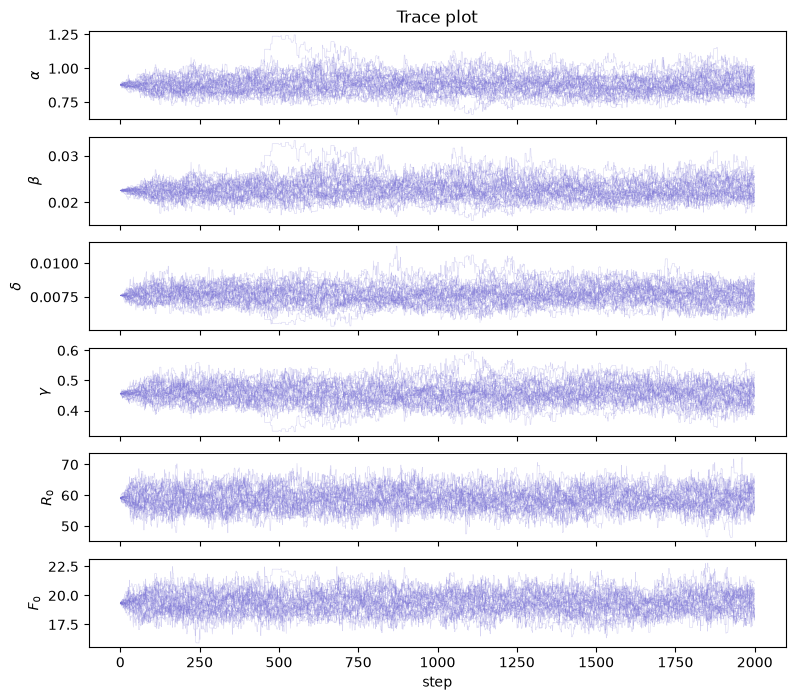

In [114]:
from bayes_tools import html_table

chain = sampler.get_chain()                               # (steps, walkers, parameters)

fig, axes = plt.subplots(6, 1, figsize=(9, 8), sharex=True)
for k, ax in enumerate(axes):
    ax.plot(chain[:, :, k], lw=0.4, alpha=0.3, color=colors[1])
    ax.set_ylabel(labels[k]); ax.grid(False)
axes[0].set_title("Trace plot")
axes[-1].set_xlabel("step")
plt.show()


#### Autocorrelation time

For a chain $x_t$ with mean $\mu$ and variance $\sigma^2$, the *autocorrelation* is

$$\rho(k) = \frac{\mathrm{E}\big[(x_t-\mu)(x_{t+k}-\mu)\big]}{\sigma^2}, \qquad \rho(0)=1$$

the correlation of the chain with a copy of itself shifted by $k$ steps. It starts at 1 and should fall to about 0 well inside the plotted lags. Failure signs: a curve still far from 0 at the right edge, or flattening above 0. The walkers forget slowly: a long ridge, a slow mode, or a chain still drifting (check the trace plot).

The *integrated autocorrelation time* is

$$\tau = 1 + 2\sum_{k=1}^{\infty}\rho(k)$$

the number of steps after which the chain has forgotten where it was. Every $\tau$ steps give about one independent sample, so $N$ steps are worth $N/\tau$ independent samples. The table gives $\tau$ for each parameter; emcee's documentation advises trusting the estimate only if the chain is longer than about $50\,\tau$, i.e. $N/\tau > 50$ (here we have a bit smaller for time reason).

parameter,τ [steps],N / τ
α,74,22
β,73,22
δ,70,23
γ,75,21
R0,50,32
F0,58,27

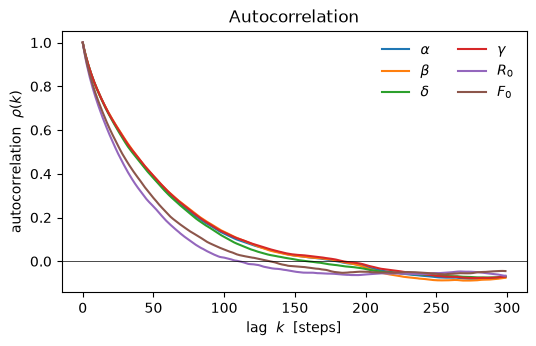

In [115]:
import io, base64
from IPython.display import HTML, display
from emcee.autocorr import function_1d

chain = sampler.get_chain(discard=400)                    # (steps, walkers, parameters), burn-in removed
tau = sampler.get_autocorr_time(discard=400, tol=0)       # one number per parameter

fig, ax = plt.subplots(figsize=(6, 3.4))
for k in range(chain.shape[2]):                           # rho(k), averaged over the walkers
    rho = np.mean([function_1d(chain[:, w, k]) for w in range(chain.shape[1])], axis=0)
    ax.plot(rho[:300], label=labels[k])
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel(r"lag  $k$  [steps]"); ax.set_ylabel(r"autocorrelation  $\rho(k)$")
ax.set_title("Autocorrelation"); ax.legend(frameon=False, ncol=2); ax.grid(False)

buf = io.BytesIO(); fig.savefig(buf, format="png", dpi=100, bbox_inches="tight"); plt.close(fig)
img = f'<img src="data:image/png;base64,{base64.b64encode(buf.getvalue()).decode()}">'

rows = [[n, f"{t:.0f}", f"{chain.shape[0] / t:.0f}"] for n, t in zip(["α", "β", "δ", "γ", "R0", "F0"], tau)]
table = html_table(["parameter", "τ  [steps]", "N / τ"], rows, rule_before_last=False).data
display(HTML(f'<div style="display:flex;align-items:center;flex-wrap:wrap;gap:24px">{img}{table}</div>'))

### What to take from Example 4.1

- **The problem:** six parameters, an ODE model, no closed form. A grid with 100 points per axis would need $10^{12}$ model runs.
- **What we wrote:** one function, `log_post`, which is prior × likelihood. The sampler (`emcee`) needs nothing else.
- **What we got:** samples of the six-dimensional posterior, from which we read the corner plot, the credible intervals and the predictions.

---

### What I skipped/missed in the course

| topic | when you need it |
|:---|:---|
| nested sampling | to compute the evidence itself, or a posterior with several modes |
| model checking | prior and posterior predictive checks |
| model comparison without the evidence | the evidence is hard to compute or too prior-dependent (cross-validation: LOO, WAIC) |
| hierarchical models | the prior has parameters of its own, e.g. a Gaussian process |
| gradient-based samplers | many parameters and a differentiable model (Hamiltonian Monte Carlo, NUTS) |
| emulators and simulation-based inference | an expensive model, or a simulator with no explicit likelihood |
| more convergence diagnostics | several chains |
| software/python libraries | Stan, ArviZ, PyMC, NumPyro, dynesty, UltraNest, MultiNest, sbi |